# Segmenter les clients à l'aide de K-Means

In [7]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import seaborn as sb
import numpy as np
from sklearn.neighbors import NearestNeighbors

In [8]:
data = pd.read_csv("../data/preprocessed_data.csv")
data

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Contract,Churn,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,1,0,0,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,1,0,0,0,0,1,0,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,0,0,0,1,0,1,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,...,1,1,0,0,0,1,0,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,...,0,0,0,0,1,0,1,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,...,1,1,1,1,1,1,0,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1,...,1,0,1,1,1,1,0,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,1,0,0,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,...,0,0,0,0,1,0,1,0.055556,0.558706,0.035303


In [9]:
X = data.drop("Churn", axis=1)
y = data.Churn

X

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Contract,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,1,0,0,0,0,1,0,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,1,0,0,0,0,1,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,1,0,0,0,0,1,0,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,...,0,1,1,0,0,0,1,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,...,0,0,0,0,0,1,0,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,...,0,1,1,1,1,1,1,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1,...,1,1,0,1,1,1,1,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,0,1,0,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,...,0,0,0,0,0,1,0,0.055556,0.558706,0.035303


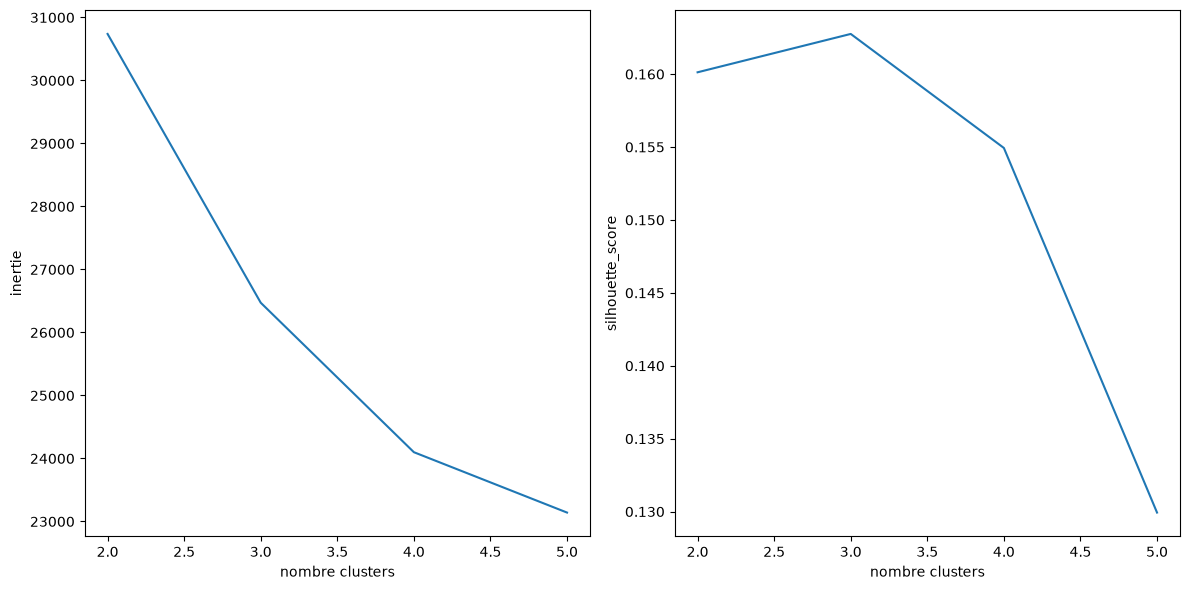

In [ ]:
# Elbow + Silhouette
inerties = []
silhouette_scores = []

for i in range(2, 6):
    kmeans_model = KMeans(
        n_clusters=i,
        random_state=11
    )
    predicted_y = kmeans_model.fit_predict(X)

    inerties.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(X, predicted_y))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(range(2, 6), inerties)
axs[0].set_xlabel('nombre clusters')
axs[0].set_ylabel('inertie')

axs[1].plot(range(2, 6), silhouette_scores)
axs[1].set_xlabel('nombre clusters')
axs[1].set_ylabel('silhouette_score')

plt.tight_layout()
plt.show()

selon le plot de la méthode Elbow le nombre de k idéal est soit 3 soit 4 mais en se basant sur le silhouette score on remarque que 3 et mieux que 4.

### min_samples
**Description** : Nombre minimum de points dans le voisinage eps pour qu’un point soit considéré comme point cœur.
<br>
**Règle pratique** : une valeur courante est min_samples ≥ D + 1 où D est la dimensionalité des données. Pour des données 2D, min_samples = 5 est un bon point de départ. Pour des données bruitées, augmentez cette valeur.

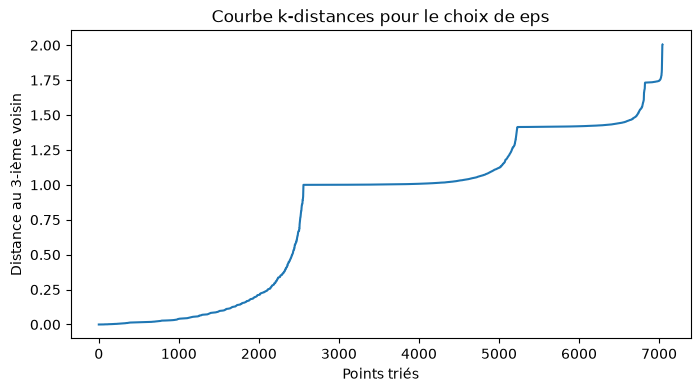

In [63]:
# Courbe k-distances pour choisir eps
k = 3
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, indices = nn.kneighbors(X)

# Trier les distances au k-ième voisin
distances_k = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 4))
plt.plot(distances_k)
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {k}-ième voisin')
plt.title('Courbe k-distances pour le choix de eps')
plt.show()

In [69]:
# DBSCAN
df = pd.DataFrame([], columns=["nb_clusters", "eps", "outliers"])
eps_range = np.arange(1, 1.76, 0.01)

for i, ep in enumerate(eps_range):
    dbscan = DBSCAN(eps=ep, min_samples=k)
    dbscan_labels = dbscan.fit_predict(X, y)
    df.loc[i] = [
        len(set(dbscan_labels))-(1 if (-1 in dbscan_labels) else 0), 
        ep,
        list(dbscan_labels).count(-1)
    ]

df

,nb_clusters,eps,outliers
0,384.0,1.00,4479.0
1,111.0,1.01,2471.0
2,96.0,1.02,2186.0
3,95.0,1.03,2025.0
4,94.0,1.04,1908.0
...,...,...,...
71,1.0,1.71,82.0
72,1.0,1.72,81.0
73,1.0,1.73,81.0
74,1.0,1.74,17.0


In [70]:
df.groupby(by="nb_clusters").aggregate("min")

,eps,outliers
nb_clusters,,
1.0,1.56,10.0
2.0,1.51,122.0
3.0,1.49,107.0
4.0,1.48,155.0
6.0,1.47,168.0
7.0,1.45,224.0
8.0,1.46,190.0
9.0,1.44,284.0
17.0,1.43,346.0


In [71]:
df[(df["nb_clusters"]==3) & (df["outliers"]==107.0)]

,nb_clusters,eps,outliers
55,3.0,1.55,107.0


le moins nombre d'outliers est repéré à la ligne 55 où on a 3 clusters avec un eps égale à 1.55 et 107 comme valeurs aberrantes.